# 🟡 Rosenbrock Function — Algorithm Comparison

**Function:** $f(x) = \sum_{i=1}^{n-1} \left[ 100(x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$ &nbsp; | &nbsp; Global minimum: $f(1,...,1) = 0$

**Properties:** Continuous · Unimodal · **Narrow curved valley** · Ill-conditioned  
**Key challenge:** The global minimum lies inside a long, narrow, banana-shaped valley.
Finding the valley is easy — crawling along it to the minimum is hard.

**Algorithms tested:**
| Category | Algorithms |
|---|---|
| Classic | HC, SA |
| Evolution | GA, DE |
| Biology | ABC, PSO |
| Human | SFO, TLBO |

---
**Run order before this notebook:**
```bash
python experiments/dim2_experiment.py rosenbrock
python experiments/convergence_experiment.py rosenbrock
python experiments/robustness_experiment.py
```

## §0 — Setup

In [6]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import Image, display
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

from problems.continuous import rosenbrock
from utils.visualize import (
    load_pkl, load_summary_csv,
    plot_contour_2d,
    plot_trajectory_2d,
    make_population_gif,
    make_trajectory_gif,
    plot_convergence,
    plot_best_vs_avg,
    plot_robustness_bar,
    plot_robustness_boxplot,
    plot_convergence_runs,
    plot_parameter_sensitivity,
    PALETTE,
)

mpl.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
plt.style.use('seaborn-v0_8-whitegrid')

RESULTS  = Path('../results')
GIFS_DIR = RESULTS / 'gifs' / 'rosenbrock'
GIFS_DIR.mkdir(parents=True, exist_ok=True)

BOUNDS  = (-2.0, 2.0)
FUNC    = rosenbrock
PROBLEM = 'Rosenbrock'
ALGOS   = ['HC', 'SA', 'GA', 'DE', 'ABC', 'PSO', 'SFO', 'TLBO']
ALGO_COLOR = {a: PALETTE[i] for i, a in enumerate(ALGOS)}

print('Setup complete.')

Setup complete.


## §1 — Load Data

In [7]:
dim2       = load_pkl(RESULTS / 'dim2_rosenbrock.pkl')
conv       = load_pkl(RESULTS / 'convergence_rosenbrock.pkl')
rob_data   = load_pkl(RESULTS / 'robustness_rosenbrock.pkl')
rob_raw    = rob_data['raw']
rob_summary = load_summary_csv(RESULTS / 'robustness_rosenbrock.csv')

def flat(pkl, dim):
    return {algo: dim_data[dim]
            for algo, dim_data in pkl.items()
            if dim in dim_data}

conv_30 = flat(conv, 30)

print('dim2 algos    :', list(dim2.keys()))
print('conv_30 algos :', list(conv_30.keys()))
print('Robustness runs:', len(rob_raw))

dim2 algos    : ['HC', 'PSO', 'GA', 'SA', 'DE', 'TLBO', 'ABC', 'SFO']
conv_30 algos : ['HC', 'SA', 'GA', 'PSO', 'DE', 'TLBO', 'ABC', 'SFO']
Robustness runs: 720


---
## §2 — Case A: 2D Visualisation
### 2.1 — Banana Valley Landscape

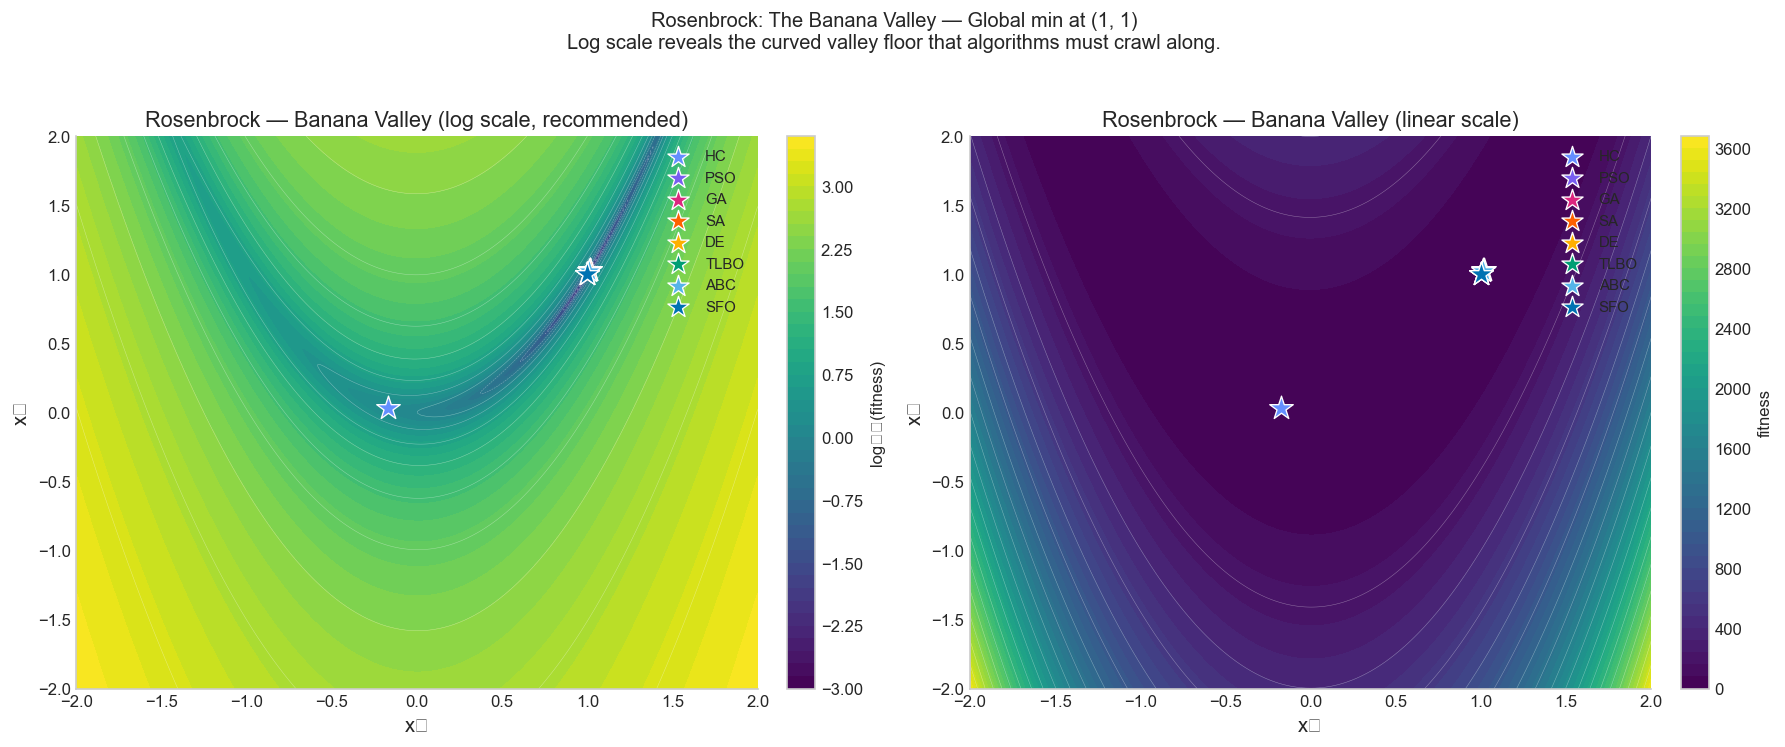

In [8]:
final_pos = {algo: data['best_solution'][:2]
             for algo, data in dim2.items()}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Log scale is ESSENTIAL for Rosenbrock — without it the valley is invisible
plot_contour_2d(
    FUNC, BOUNDS, final_positions=final_pos,
    log_scale=True,
    title='Rosenbrock — Banana Valley (log scale, recommended)',
    ax=axes[0],
)
plot_contour_2d(
    FUNC, BOUNDS, final_positions=final_pos,
    log_scale=False,
    title='Rosenbrock — Banana Valley (linear scale)',
    ax=axes[1],
)

plt.suptitle(
    'Rosenbrock: The Banana Valley — Global min at (1, 1)\n'
    'Log scale reveals the curved valley floor that algorithms must crawl along.',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig(RESULTS / 'rosenbrock_contour_2d.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 — HC vs SA: Valley-Crawling Trajectories
**Key insight:** HC crawls carefully along the valley floor. SA may jump across it.

IndexError: too many indices for array: array is 0-dimensional, but 2 were indexed

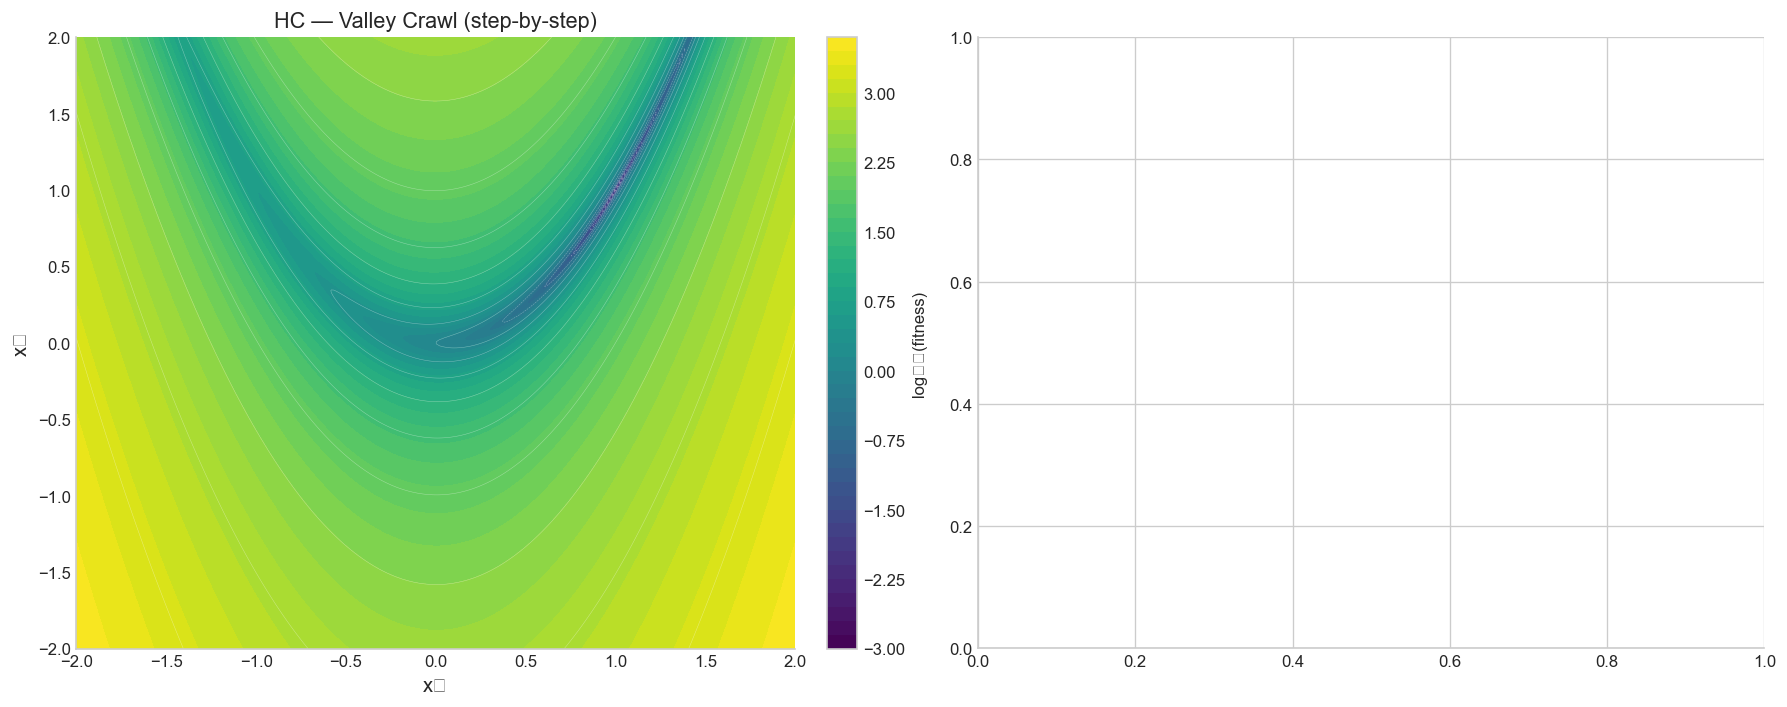

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_trajectory_2d(
    FUNC, BOUNDS,
    trajectories={'HC': dim2['HC']['trajectory']},
    log_scale=True,
    title='HC — Valley Crawl (step-by-step)',
    ax=axes[0],
)
plot_trajectory_2d(
    FUNC, BOUNDS,
    trajectories={'SA': dim2['SA']['trajectory']},
    log_scale=True,
    title='SA — Valley Navigation (with temperature jumps)',
    ax=axes[1],
)

plt.suptitle('HC vs SA: Exploiting the Narrow Valley (2D)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / 'rosenbrock_hc_vs_sa_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Animated trajectory GIFs
for algo in ['HC', 'SA']:
    gif_path = GIFS_DIR / f'{algo}_trajectory.gif'
    make_trajectory_gif(
        FUNC, BOUNDS, dim2[algo]['trajectory'], algo,
        gif_path, n_frames=60, fps=10, log_scale=True,
    )
    print(f'\n{algo} trajectory:')
    display(Image(filename=gif_path))

### 2.3 — Population GIFs (GA, DE, ABC, PSO, SFO, TLBO)

In [ ]:
POP_ALGOS = ['GA', 'DE', 'ABC', 'PSO', 'SFO', 'TLBO']

for algo in POP_ALGOS:
    if algo not in dim2:
        print(f'{algo}: not found, skipping.')
        continue
    gif_path = GIFS_DIR / f'{algo}_population.gif'
    make_population_gif(
        FUNC, BOUNDS,
        dim2[algo]['population_history'],
        algo, gif_path,
        best_history=dim2[algo]['trajectory'],
        n_frames=60, fps=10, log_scale=True,   # log scale reveals the valley
    )
    print(f'\n{algo} population:')
    display(Image(filename=gif_path))

---
## §3 — Case B: 30D Analysis
### 3.1 — Parameter Sensitivity

We vary one hyperparameter at a time for HC, GA, and DE, running live in this notebook.  
All other settings are kept at their config defaults. `max_iter=500` for fairness.

In [10]:
# ── Shared sensitivity runner ────────────────────────────────────────────────
import numpy as np
import sys
sys.path.insert(0, '..')

from utils.configHelper import load_config, get_algorithm_params
from algorithms.classic.local_search import HillClimbingContinuous
from algorithms.evolution.GA import GA
from algorithms.evolution.DE import DE

config = load_config('../utils/config.json')

SENS_DIM      = 30
SENS_ITER     = 500
SENS_SEED     = 42
lo, hi        = BOUNDS
sens_bounds   = np.array([[lo, hi]] * SENS_DIM)

def run_sensitivity(algo_class, fixed_kwargs, param_name, param_values, seed=SENS_SEED):
    """
    Run algo_class once per param_value, varying param_name.
    Returns dict {param_value: convergence_curve np.ndarray}
    """
    results = {}
    for val in param_values:
        np.random.seed(seed)
        kwargs = {**fixed_kwargs, param_name: val}
        algo   = algo_class(**kwargs)
        out    = algo.solve()
        results[val] = out['convergence_curve']
        print(f'  {param_name}={val:<8}  best={out["best_fitness"]:.4e}')
    return results

print('Sensitivity runner ready.')

Sensitivity runner ready.


In [11]:
# ── HC: step_size sensitivity ────────────────────────────────────────────────
print('HC — step_size sensitivity')
hc_params = get_algorithm_params('HC', 'rosenbrock', SENS_DIM, config)

HC_STEP_SIZES = [0.01, 0.1, 0.5, 1.0, 2.0]

hc_sens = run_sensitivity(
    HillClimbingContinuous,
    fixed_kwargs=dict(
        objective_func=FUNC,
        bounds=sens_bounds, dim=SENS_DIM,
        pop_size=hc_params.get('population_size', 10),
        max_iter=SENS_ITER,
        step_decay=hc_params.get('step_decay', 0.995),
        max_restarts=hc_params.get('max_restarts', 10),
        patience=hc_params.get('patience', 30),
    ),
    param_name='step_size',
    param_values=HC_STEP_SIZES,
)

HC — step_size sensitivity
  step_size=0.01      best=1.3753e+03
  step_size=0.1       best=2.9548e+01
  step_size=0.5       best=3.3806e+01
  step_size=1.0       best=6.0264e+01
  step_size=2.0       best=1.3425e+03


In [12]:
# ── GA: mutation_rate sensitivity ────────────────────────────────────────────
print('GA — mutation_rate sensitivity')
ga_params = get_algorithm_params('GA', 'rosenbrock', SENS_DIM, config)

GA_MUT_RATES = [0.01, 0.05, 0.1, 0.2, 0.5]

ga_sens = run_sensitivity(
    GA,
    fixed_kwargs=dict(
        objective_func=FUNC,
        bounds=sens_bounds, dim=SENS_DIM,
        pop_size=ga_params.get('population_size', 50),
        max_iter=SENS_ITER,
        crossover_rate=ga_params.get('crossover_rate', 0.8),
        mutation_scale=ga_params.get('mutation_scale', 0.1),
        tournament_size=ga_params.get('tournament_size', 3),
    ),
    param_name='mutation_rate',
    param_values=GA_MUT_RATES,
)

GA — mutation_rate sensitivity
  mutation_rate=0.01      best=2.8079e+01
  mutation_rate=0.05      best=2.8287e+01
  mutation_rate=0.1       best=3.1828e+01
  mutation_rate=0.2       best=4.8592e+01
  mutation_rate=0.5       best=1.5594e+02


In [13]:
# ── DE: mutation factor F sensitivity ────────────────────────────────────────
print('DE — F (mutation factor) sensitivity')
de_params = get_algorithm_params('DE', 'rosenbrock', SENS_DIM, config)

DE_F_VALUES = [0.2, 0.5, 0.8, 1.0, 1.2]

de_sens = run_sensitivity(
    DE,
    fixed_kwargs=dict(
        objective_func=FUNC,
        bounds=sens_bounds, dim=SENS_DIM,
        pop_size=de_params.get('population_size', 50),
        max_iter=SENS_ITER,
        CR=de_params.get('crossover_rate', 0.9),
    ),
    param_name='F',
    param_values=DE_F_VALUES,
)

DE — F (mutation factor) sensitivity
  F=0.2       best=1.1871e+02
  F=0.5       best=2.6820e+01
  F=0.8       best=3.1393e+02
  F=1.0       best=3.7405e+03
  F=1.2       best=7.9947e+03


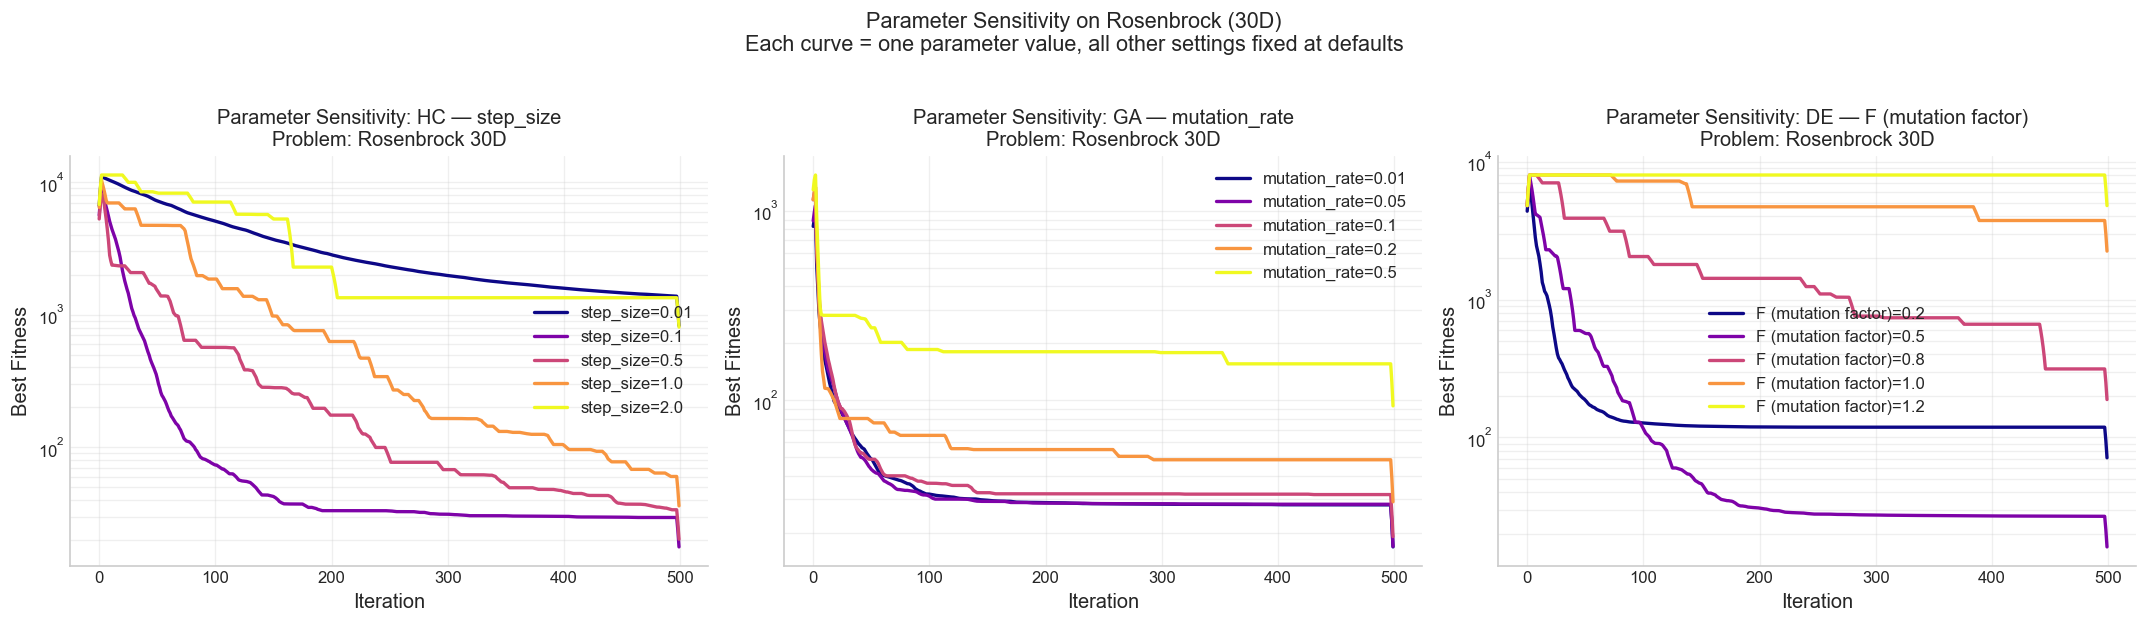

In [14]:
# ── Plot all three sensitivity analyses ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_parameter_sensitivity(
    hc_sens, param_name='step_size', param_values=HC_STEP_SIZES,
    algo_name='HC', problem=f'{PROBLEM} {SENS_DIM}D',
    log_scale=True, smooth_window=5, ax=axes[0],
)
plot_parameter_sensitivity(
    ga_sens, param_name='mutation_rate', param_values=GA_MUT_RATES,
    algo_name='GA', problem=f'{PROBLEM} {SENS_DIM}D',
    log_scale=True, smooth_window=5, ax=axes[1],
)
plot_parameter_sensitivity(
    de_sens, param_name='F (mutation factor)', param_values=DE_F_VALUES,
    algo_name='DE', problem=f'{PROBLEM} {SENS_DIM}D',
    log_scale=True, smooth_window=5, ax=axes[2],
)

plt.suptitle(
    'Parameter Sensitivity on Rosenbrock (30D)\n'
    'Each curve = one parameter value, all other settings fixed at defaults',
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.savefig(RESULTS / 'rosenbrock_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 — Convergence Curves (All 8 Algorithms)

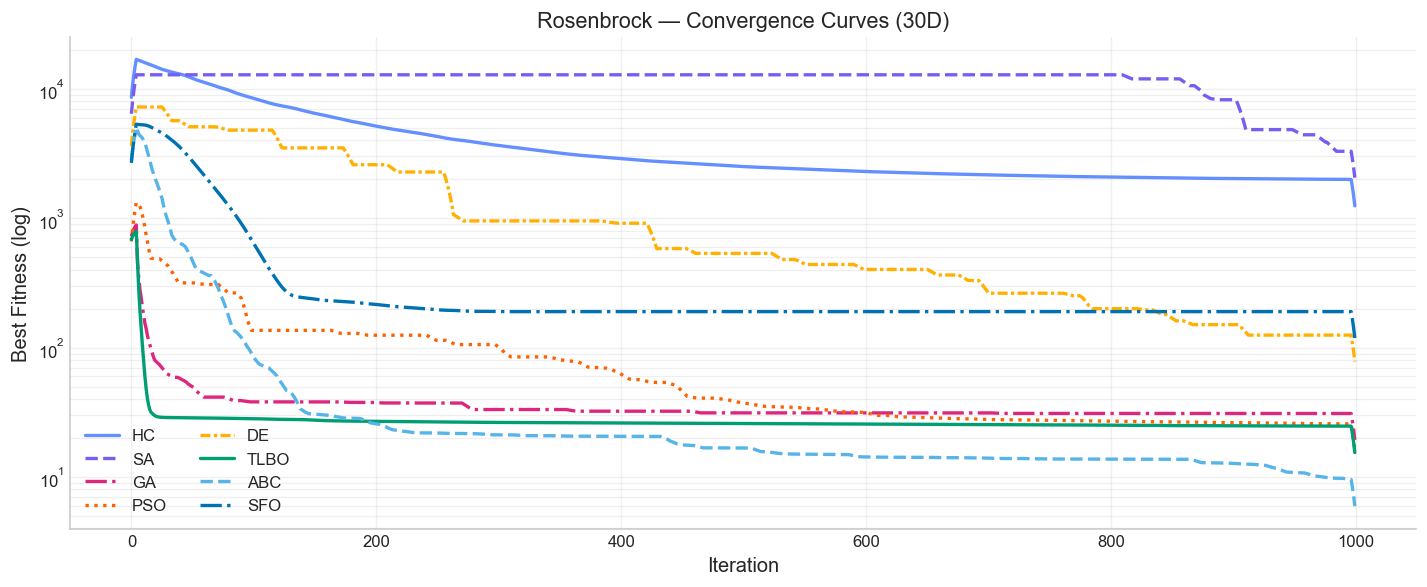

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_convergence(
    conv_30, problem=PROBLEM, log_scale=True, smooth_window=8,
    title='Rosenbrock — Convergence Curves (30D)',
    ax=ax,
)
plt.tight_layout()
plt.savefig(RESULTS / 'rosenbrock_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 — Best vs Average Solution Quality

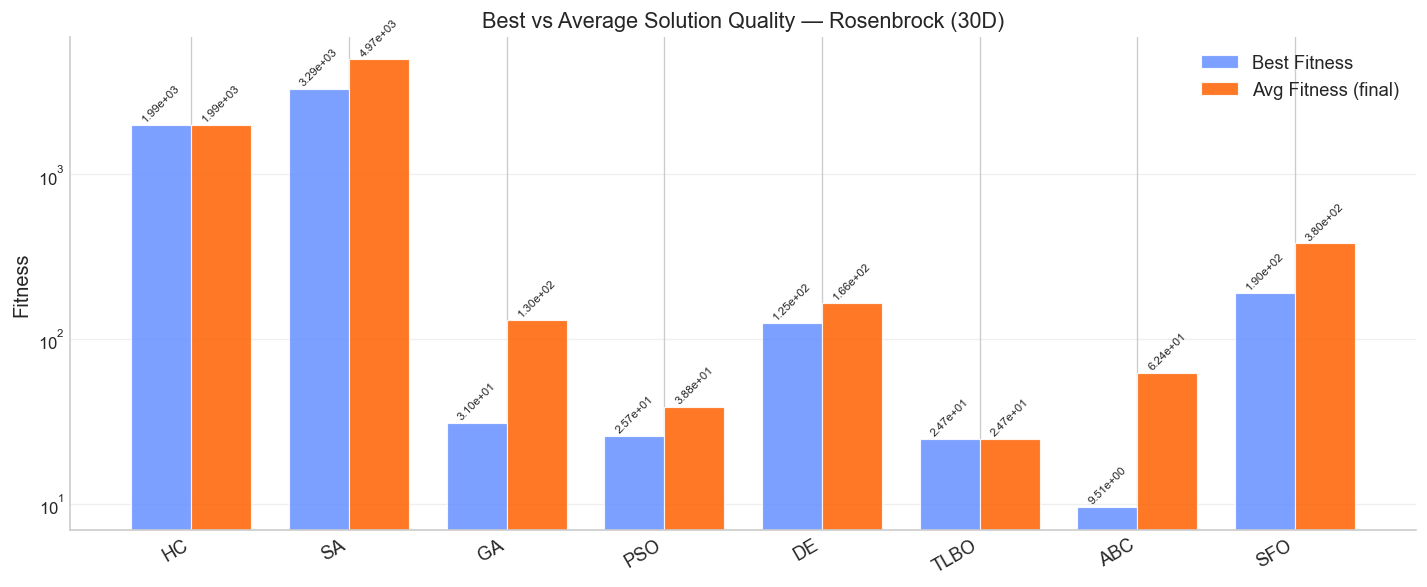

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_best_vs_avg(
    conv_30, problem=PROBLEM, dim=30,
    log_scale=True, ax=ax,
)
plt.tight_layout()
plt.savefig(RESULTS / 'rosenbrock_quality.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 — Robustness: 30 Independent Runs

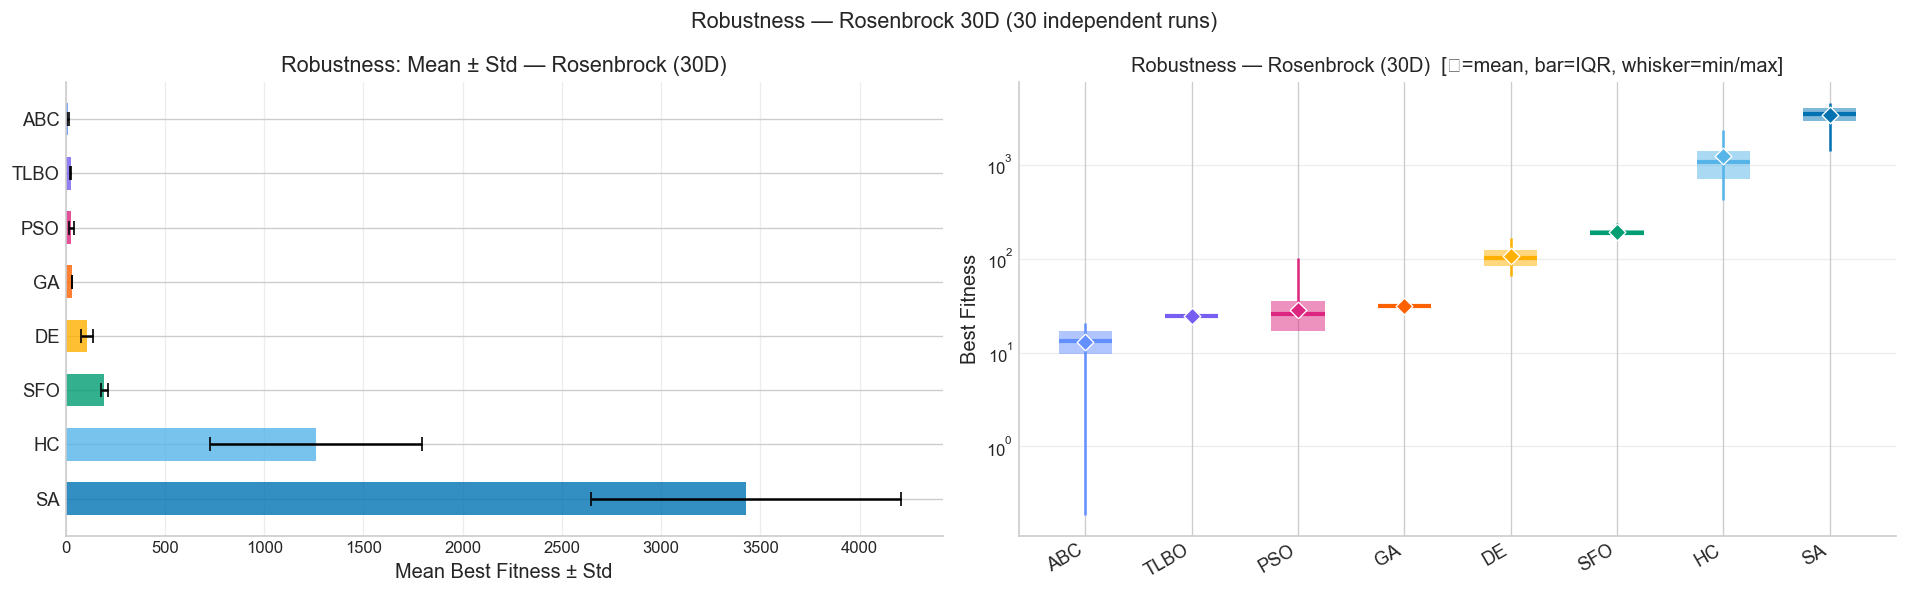

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_robustness_bar(
    rob_summary, dim=30, problem=PROBLEM, ax=axes[0]
)
plot_robustness_boxplot(
    rob_summary, dim=30, problem=PROBLEM, log_scale=True, ax=axes[1]
)
plt.suptitle('Robustness — Rosenbrock 30D (30 independent runs)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / 'rosenbrock_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

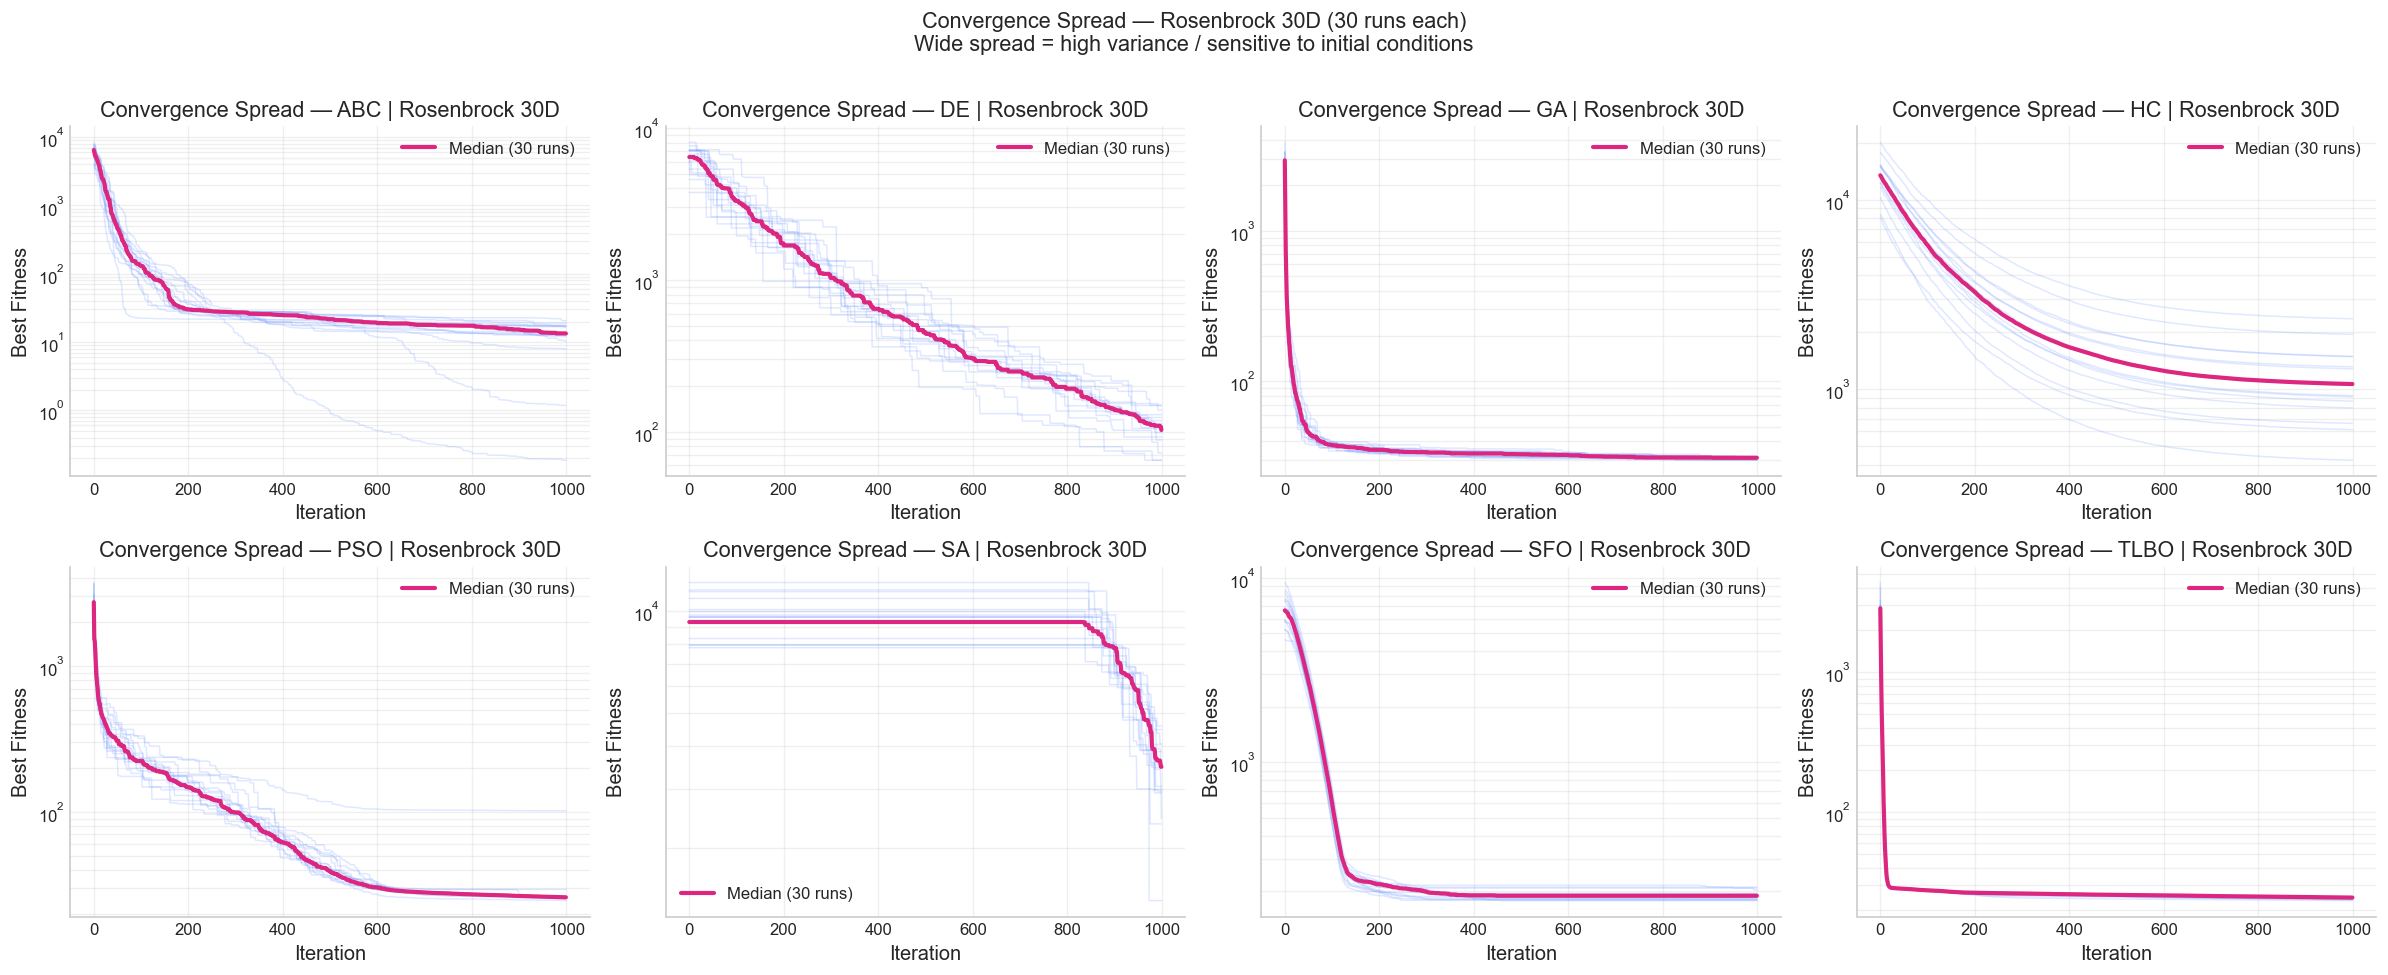

In [18]:
# Per-algorithm spaghetti plots (all 30 convergence curves)
algos_in_rob = sorted(set(r['algorithm'] for r in rob_raw))
ncols = 4
nrows = (len(algos_in_rob) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
axes_flat = axes.flatten()

for i, algo in enumerate(algos_in_rob):
    algo_runs = [r for r in rob_raw
                 if r['algorithm'] == algo and r.get('dimensions') == 30]
    plot_convergence_runs(
        algo_runs, algorithm=algo,
        dim=30, problem=PROBLEM,
        log_scale=True, ax=axes_flat[i],
    )

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    'Convergence Spread — Rosenbrock 30D (30 runs each)\n'
    'Wide spread = high variance / sensitive to initial conditions',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(RESULTS / 'rosenbrock_spaghetti.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 — Robustness Summary Table

In [19]:
df30 = rob_summary[rob_summary['dimensions'] == 30].copy()
df30 = df30.sort_values('mean_fitness').reset_index(drop=True)

display_df = df30[[
    'algorithm', 'mean_fitness', 'std_fitness',
    'min_fitness', 'median_fitness', 'max_fitness', 'mean_time'
]].copy()

for col in ['mean_fitness', 'std_fitness', 'min_fitness',
            'median_fitness', 'max_fitness']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.3e}')
display_df['mean_time'] = display_df['mean_time'].apply(lambda x: f'{x:.2f}s')

display_df.columns = [
    'Algorithm', 'Mean', 'Std', 'Min', 'Median', 'Max', 'Avg Time'
]

print('Robustness Summary — Rosenbrock 30D (30 runs, sorted by mean)\n')
print(display_df.to_string(index=False))

Robustness Summary — Rosenbrock 30D (30 runs, sorted by mean)

Algorithm      Mean       Std       Min    Median       Max Avg Time
      ABC 1.293e+01 5.414e+00 1.858e-01 1.335e+01 2.058e+01   10.05s
     TLBO 2.451e+01 3.851e-01 2.339e+01 2.459e+01 2.511e+01    4.61s
      PSO 2.835e+01 1.364e+01 2.275e+01 2.596e+01 1.016e+02    0.39s
       GA 3.103e+01 7.482e-01 2.990e+01 3.105e+01 3.277e+01    0.58s
       DE 1.065e+02 2.937e+01 6.483e+01 1.026e+02 1.661e+02    2.42s
      SFO 1.951e+02 1.638e+01 1.774e+02 1.891e+02 2.423e+02   55.92s
       HC 1.260e+03 5.333e+02 4.217e+02 1.065e+03 2.356e+03    0.07s
       SA 3.426e+03 7.816e+02 1.402e+03 3.476e+03 4.597e+03    0.29s


---
## §4 — Summary Observations

| Observation | Expected | Actual |
|---|---|---|
| Best algorithm overall | DE or PSO | — |
| Most consistent (lowest std) | PSO / TLBO | — |
| HC step_size sweet spot | 0.1–0.5 | — |
| GA mutation_rate too high → | Noisy, slow convergence | — |
| DE F too low → | Premature convergence | — |
| SFO valley navigation | Should track valley naturally | — |